# Figure 5 notebook - this focuses on TCs

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# setup all the imports
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import seaborn as sns
import extremeweatherbench as ewb
sns.set_theme(style='whitegrid')
import shapely
from pathlib import Path
import multiprocessing
import xarray as xr
from matplotlib.lines import Line2D
import cartopy.crs as ccrs  # noqa: E402
import datetime

# make the basepath - change this to your local path
basepath = Path.home() / "code" / "extreme-weather-bench-paper" / ""
basepath = str(basepath) + "/"

import src.plots.plotting_utils as plot_utils  # noqa: E402
import src.plots.results_utils as results_utils  # noqa: E402
import src.plots.atmospheric_river_utils as ar_plot_utils  # noqa: E402
import src.plots.plotting_styles as ps  # noqa: E402


In [3]:
# load in all of the events in the yaml file
print("loading in the events yaml file")
ewb_cases = ewb.cases.load_ewb_events_yaml_into_case_list()

# subset all the cases to only include the tc cases
ewb_cases = [c for c in ewb_cases if c.event_type == "tropical_cyclone"]

case_operators = ewb.cases.build_case_operators(
    ewb_cases, ewb.defaults.get_brightband_evaluation_objects()
)

loading in the events yaml file


In [4]:
# to plot the targets, we need to run the pipeline for each case and target
from joblib import Parallel, delayed  # noqa: E402
from joblib.externals.loky import get_reusable_executor  # noqa: E402
import os
import pickle
# load in all the case info (note this takes awhile in non-parallel form as it has to
# run all the target information for each case)
# this will return a list of tuples with the case id and the target dataset

case_operators_exist = os.path.exists(basepath + 'saved_data/case_operators_with_targets_established.pkl')
if not case_operators_exist:
    print("running the pipeline for each case and target")
    parallel = Parallel(n_jobs=32, return_as="generator", backend="loky")
    case_operators_with_targets_established_generator = parallel(
        delayed(
            lambda co: (
                co.case_metadata.case_id_number,
                ewb.evaluate.run_pipeline(co.case_metadata, co.target),
            )
        )(case_operator)
        for case_operator in case_operators
    )
    case_operators_with_targets_established = list(
        case_operators_with_targets_established_generator
    )
    # this will throw a bunch of errors below but they're not consequential. this releases
    # the memory as it shuts down the workers
    get_reusable_executor().shutdown(wait=True)
    pickle.dump(case_operators_with_targets_established, open(basepath + 'saved_data/case_operators_with_targets_established.pkl', 'wb'))

else:
    case_operators_with_targets_established = pd.read_pickle(basepath + 'saved_data/case_operators_with_targets_established.pkl')


In [5]:
import copy

def get_target_ds(case_operator: "cases.CaseOperator") -> xr.Dataset:
    """Get the target dataset for a case operator.

    Args:
        case_operator: The case operator to get the target dataset for.

    Returns:
        The target dataset.
    """
    metric_forecast_vars, metric_target_vars = ewb.evaluate._collect_metric_variables(
        case_operator.metric_list
    )
    target_derived_outputs = ewb.evaluate._get_all_derived_output_variables(
        case_operator.target.variables
    )
    filtered_target_vars = {
        v
        for v in metric_target_vars
        if not (isinstance(v, str) and v in target_derived_outputs)
    }
    augmented_target = copy.copy(case_operator.target)
    augmented_target.variables = list(
        set(case_operator.target.variables) | filtered_target_vars
    )
    target_ds = ewb.evaluate.run_pipeline(
        case_operator.case_metadata, augmented_target
    )
    return target_ds

In [6]:
# now compute landfalls for each case (do it in parallel as it is a bit slow in serial)
all_landfalls = []

parallel = Parallel(n_jobs=24, return_as="generator", backend="loky")
landfalls_generator = parallel(
    delayed(
        lambda co: (
            co.case_metadata.case_id_number,
            ewb.calc.find_landfalls(get_target_ds(co)['surface_wind_speed'])
        )
    )(case_operator)
    for case_operator in case_operators
)
landfalls = list(landfalls_generator)

/home/taylor/code/ExtremeWeatherBench/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/taylor/code/ExtremeWeatherBench/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/taylor/code/ExtremeWeatherBench/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/taylor/code/ExtremeWeatherBench/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while s

In [7]:
landfalls_dict = {n: m for n, m in landfalls}

In [36]:
# load the results back in
MAX_LEAD_TIME = pd.Timedelta(days=10)
TC_LEAD_TIME_DAYS = [1, 3, 5, 7, 10]
DEDUP_COLS = ['init_time', 'case_id_number', 'metric', 'target_variable']

def _load_and_filter_tc_results(path, landfalls_dict, max_lead_time):
    df = pd.read_pickle(path)
    # df = df.drop_duplicates(subset=DEDUP_COLS)
    df['lead_time'] = pd.to_timedelta(
        results_utils._compute_lead_time_to_landfall(df, landfalls_dict),
        unit='h',
    )
    df['lead_time'] = results_utils._snap_lead_time_to_bins(
        df['lead_time'], TC_LEAD_TIME_DAYS,
    )
    return df[df['lead_time'] <= max_lead_time]

hres_tc_results = _load_and_filter_tc_results(
    basepath + 'saved_data/hres_tc_results_next.pkl', landfalls_dict, MAX_LEAD_TIME)
pangu_tc_results = _load_and_filter_tc_results(
    basepath + 'saved_data/bb_pangu_tc_results_next.pkl', landfalls_dict, MAX_LEAD_TIME)
gc_tc_results = _load_and_filter_tc_results(
    basepath + 'saved_data/bb_graphcast_tc_results_next.pkl', landfalls_dict, MAX_LEAD_TIME)
aifs_tc_results = _load_and_filter_tc_results(
    basepath + 'saved_data/bb_aifs_tc_results_next.pkl', landfalls_dict, MAX_LEAD_TIME)

In [39]:
# some of them don't actually make landfall in IBTrACS (which is odd but just ignore them for now)
no_landfalls = []
landfall_case_ids = []
landfall_info = []
for i, (case_id, landfall_da) in enumerate(landfalls):
    if (len(landfall_da.valid_time) == 0):
        print("no landfalls for case", case_id)
        no_landfalls.append(case_id)
    else:
        landfall_case_ids.append(case_id)
        landfall_info.append(landfalls[i])

len(landfall_case_ids)
len(no_landfalls)


0

In [40]:
# make the bounding boxes for the regions

# WH Basins
ab_bounding_box = [-120, -45, 7, 85]
ab_bounding_box_polygon = plot_utils.get_polygon_from_bounding_box(ab_bounding_box)
ab_bounding_region = ewb.regions.BoundingBoxRegion(latitude_min=7, latitude_max=85, longitude_min=-120, longitude_max=-45)

# EH Basins
pb_bounding_box = [60, 150, -50, 50]
pb_bounding_box_polygon = plot_utils.get_polygon_from_bounding_box(pb_bounding_box)
pb_bounding_region = ewb.regions.BoundingBoxRegion(latitude_min=-50, latitude_max=50, longitude_min=60, longitude_max=150)

# break the cases into different lists
ab_subset = ewb.regions.RegionSubsetter(region=ab_bounding_region, method='intersects').subset_case_list(ewb_cases)
pb_subset = ewb.regions.RegionSubsetter(region=pb_bounding_region, method='intersects').subset_case_list(ewb_cases)
ab_case_ids = [n.case_id_number for n in ab_subset]
pb_case_ids = [n.case_id_number for n in pb_subset]

print(f'WH Basins Cases: {ab_case_ids}')
print(f'EH Basins Cases: {pb_case_ids}')


WH Basins Cases: [151, 152, 153, 154, 155, 156, 170, 172, 173, 174, 175, 176, 177, 178, 179, 180, 194, 195, 196, 197, 198, 199, 200, 201, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244]
EH Basins Cases: [158, 159, 160, 161, 162, 163, 164, 165, 167, 168, 169, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 202, 203, 204, 205, 206, 207, 208, 210, 212, 226, 227, 229, 230, 232, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256]


/home/taylor/code/extreme-weather-bench-paper/src/plots/plotting_utils.py:1359: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower left", fontsize=12)
/home/taylor/code/extreme-weather-bench-paper/src/plots/plotting_utils.py:1359: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower left", fontsize=12)


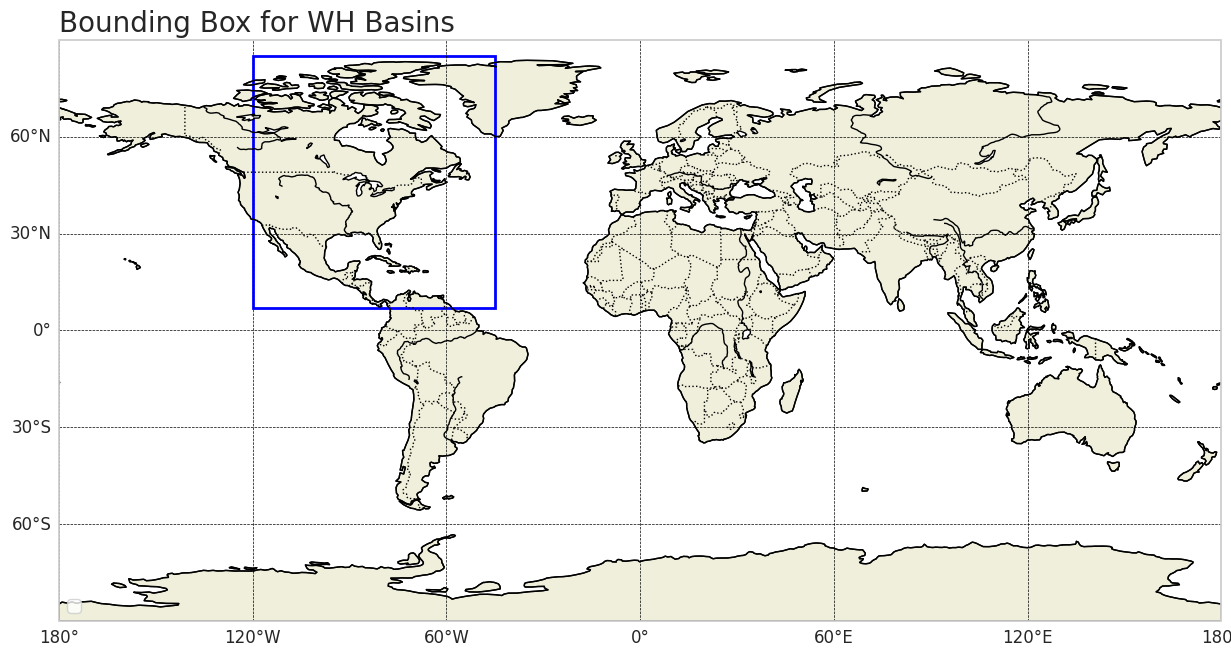

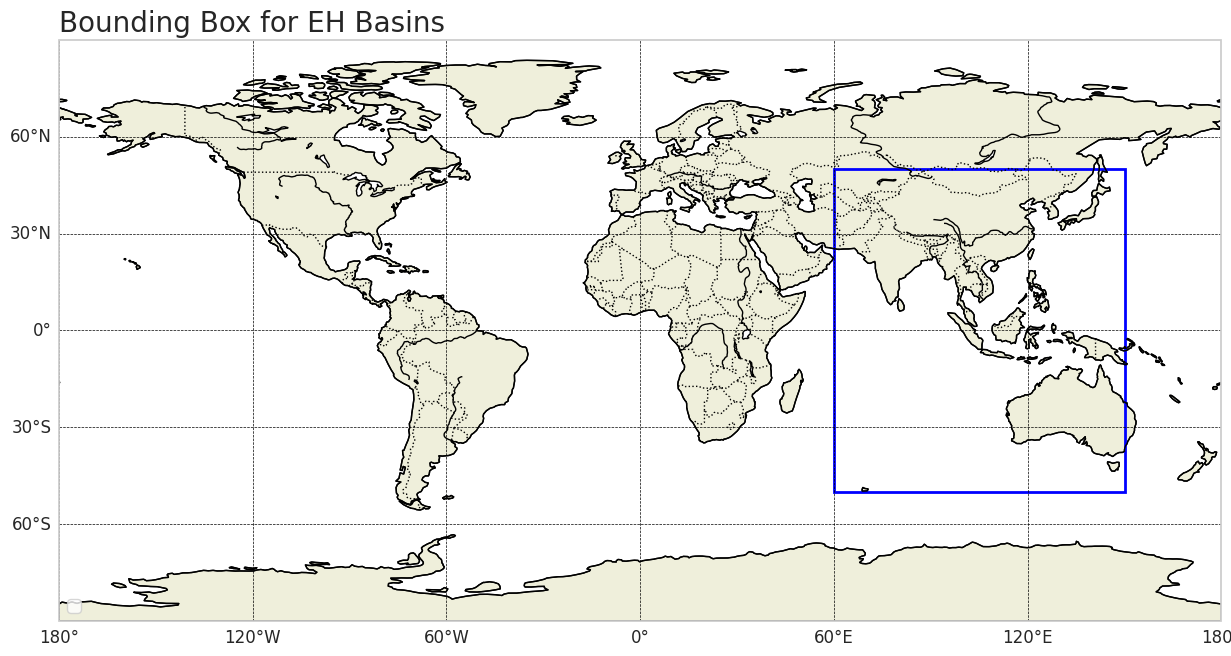

In [41]:
from shapely.geometry import Polygon

# helper functions to make the main plotting function cleaner
# helper function to convert a bounding box tuple to a shapely Polygon
def get_polygon_from_bounding_box(bounding_box):
    """Convert a bounding box tuple to a shapely Polygon."""
    if bounding_box is None:
        return None
    left_lon, right_lon, bot_lat, top_lat = bounding_box
    return Polygon(
        [
            (left_lon, bot_lat),
            (right_lon, bot_lat),
            (right_lon, top_lat),
            (left_lon, top_lat),
            (left_lon, bot_lat),
        ]
    )

# plot the bounding box we will use for the non-event days
bounding_box_polygon = get_polygon_from_bounding_box(ab_bounding_box)
plot_utils.plot_boxes([bounding_box_polygon], [], title="Bounding Box for WH Basins")

# plot the bounding box for the EH Basins
bounding_box_polygon = get_polygon_from_bounding_box(pb_bounding_box)
plot_utils.plot_boxes([bounding_box_polygon], [], title="Bounding Box for EH Basins")


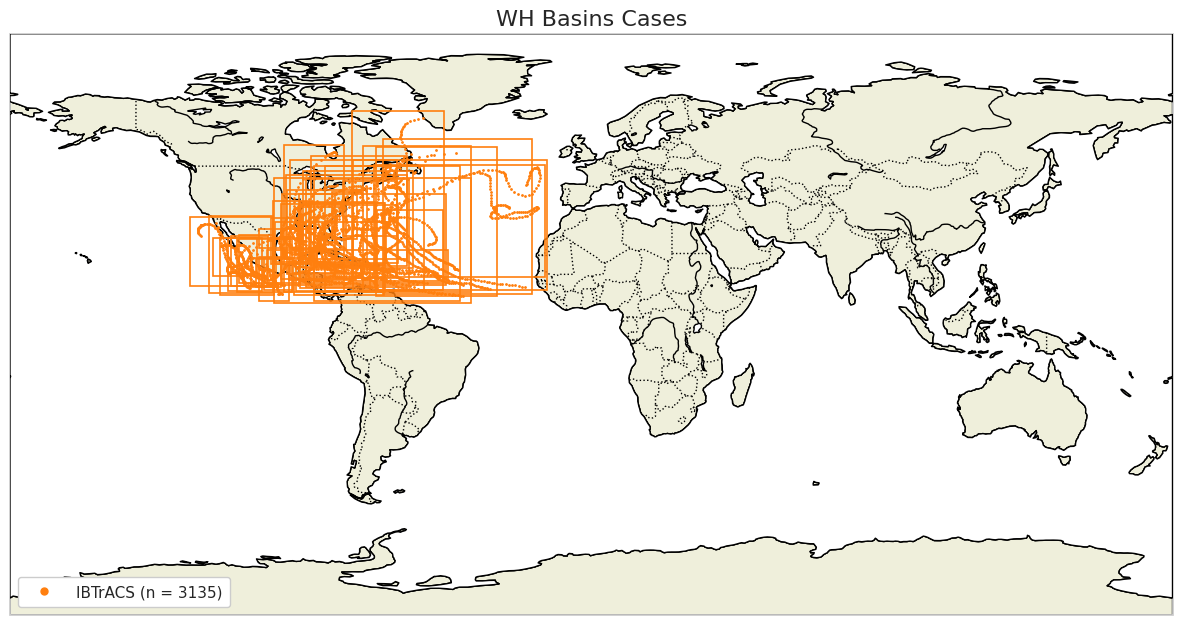

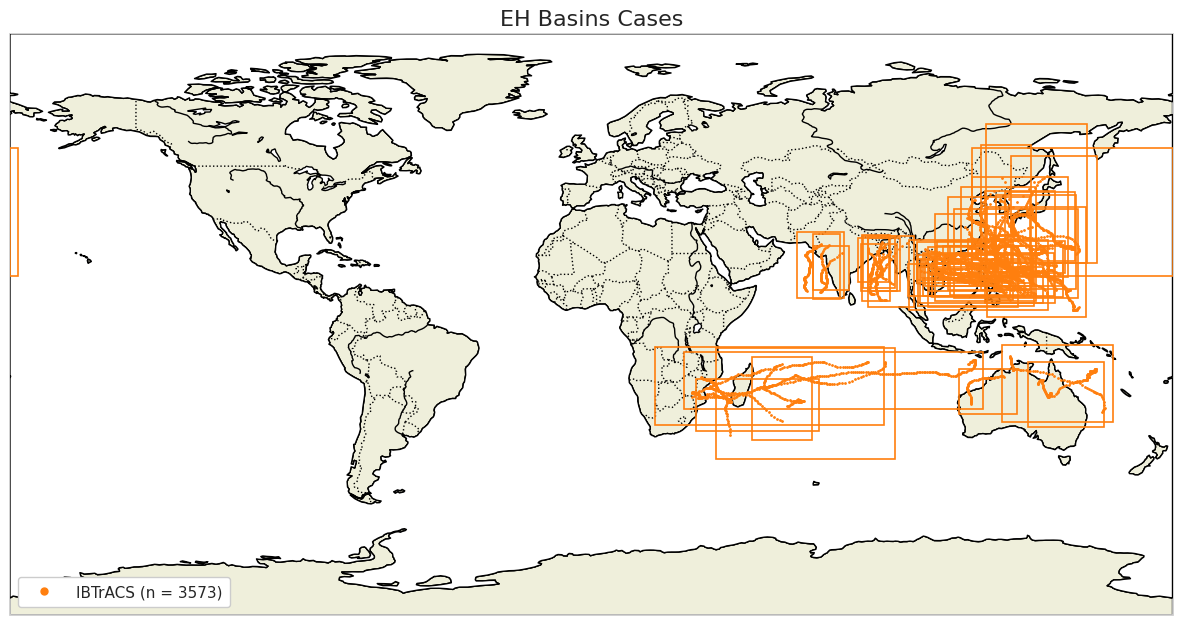

In [42]:
# plot the cases inside the bounding boxes
plot_utils.plot_all_cases_and_obs(ab_subset, event_type="tropical_cyclone", 
    targets=case_operators_with_targets_established, title="WH Basins Cases")
plot_utils.plot_all_cases_and_obs(pb_subset, event_type="tropical_cyclone", 
    targets=case_operators_with_targets_established, title="EH Basins Cases")


In [65]:
# for landfall_intensity do both target variables: surface_wind_speed and air_pressure_at_mean_sea_level
# for all other metrics, they are equal so just use surface_wind_speed
# 

def get_error_array_for_heatmap(case_list, results_array, hres_results, forecast_sources, 
    target_source, metric_strs, lead_time_days, higher_is_better_list, case_ids=None,
    target_variable=None, landfalls=None, key_strs=None, snap_lead_times=False):
    """
    This function takes in an array of results and parameters to say which results to grab and returns 
    error arrays and relative arrays for global, north america, and europe.
    """
    rel_error = {}
    error = {}

    for i, metric in enumerate(metric_strs):
        key = key_strs[i] if key_strs else metric
        rel_error[key] = np.zeros((len(results_array), len(lead_time_days)))
        error[key] = np.zeros((len(results_array), len(lead_time_days)))

        higher_is_better = higher_is_better_list[i]

        for j, results_df in enumerate(results_array):
            my_mean, my_relative_error = results_utils.compute_relative_error(
                ewb_cases=case_list, 
                results_df=results_df, 
                forecast_source=forecast_sources[j], 
                comparison_results_df=hres_results, 
                comparison_forecast_source=ps.hres_settings['forecast_source'], 
                target_source=target_source[i], 
                metric=metric, lead_time_days=lead_time_days, 
                case_ids=case_ids,
                higher_is_better=higher_is_better, target_variable=target_variable[i],
                snap_lead_times=snap_lead_times)

            if (len(my_mean) == 0):
                print(f'metric: {metric}, forecast_source: {forecast_sources[j]}')
                print(results_df)

            error[key][j, :] = my_mean
            rel_error[key][j, :] = my_relative_error


    return error, rel_error

# setup for the scorecard
# Grab means for each metric for each model
tc_metric_str = ['landfall_intensity_mae', 'landfall_intensity_mae', 'landfall_time_me', 'landfall_displacement']
tc_display_str = ['Landfall Wind Speed MAE', 'Landfall Min Pressure MAE', 'Landfall Time ME', 'Landfall Displacement']
target_variable = ['surface_wind_speed', 'air_pressure_at_mean_sea_level', 'surface_wind_speed', 'surface_wind_speed']
tc_metric_higher_is_better = [False, False, False, False]
target_source = ['IBTrACS', 'IBTrACS', 'IBTrACS', 'IBTrACS']

lead_time_days = [1, 3, 5, 7, 10]

tc_results_array = [hres_tc_results.dropna(subset=['value']), gc_tc_results.dropna(subset=['value']), pangu_tc_results.dropna(subset=['value']), aifs_tc_results.dropna(subset=['value'])]
forecast_source = [ps.hres_ifs_settings['forecast_source'],
    ps.bb_graphcast_settings['forecast_source'],
    ps.bb_pangu_settings['forecast_source'],
    ps.bb_aifs_settings['forecast_source']]

(global_tc_error, global_rel_tc_error) = get_error_array_for_heatmap(ewb_cases, 
    tc_results_array, hres_tc_results, forecast_source, target_source, tc_metric_str, 
    lead_time_days, tc_metric_higher_is_better, target_variable=target_variable,
    landfalls=landfalls, key_strs=tc_display_str, snap_lead_times=True)
(ab_tc_error, ab_rel_tc_error) = get_error_array_for_heatmap(ewb_cases, tc_results_array, 
    hres_tc_results, forecast_source, target_source, tc_metric_str, lead_time_days, 
    tc_metric_higher_is_better, case_ids=ab_case_ids, target_variable=target_variable,
    landfalls=landfalls, key_strs=tc_display_str, snap_lead_times=True)
(pb_tc_error, pb_rel_tc_error) = get_error_array_for_heatmap(ewb_cases, tc_results_array, 
    hres_tc_results, forecast_source, target_source, tc_metric_str, lead_time_days, 
    tc_metric_higher_is_better, case_ids=pb_case_ids, target_variable=target_variable,
    landfalls=landfalls, key_strs=tc_display_str, snap_lead_times=True)




Text(0.5, 1.0, 'HRES')

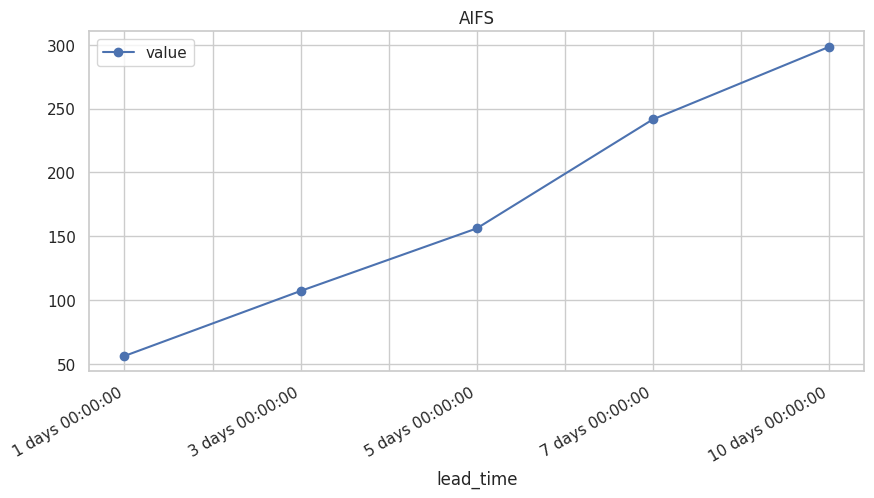

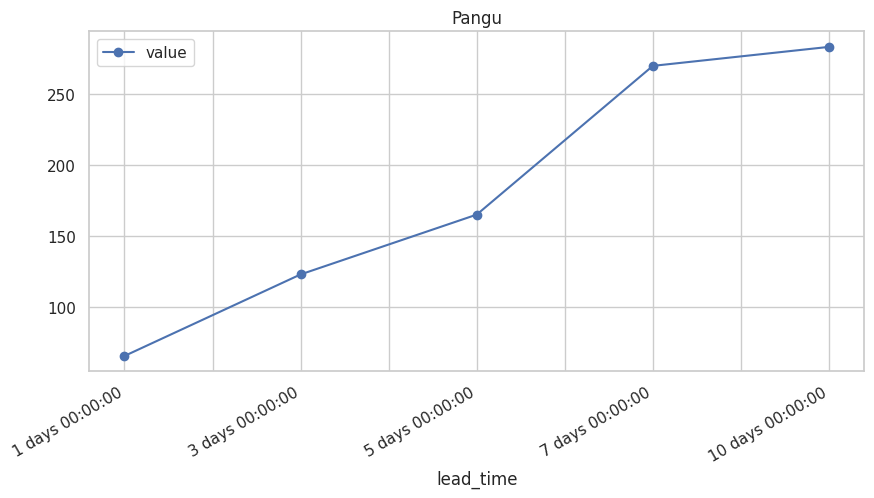

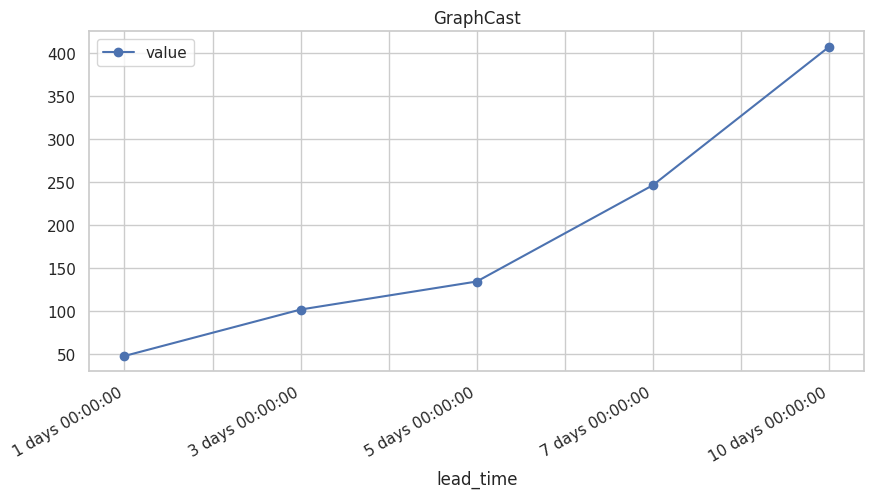

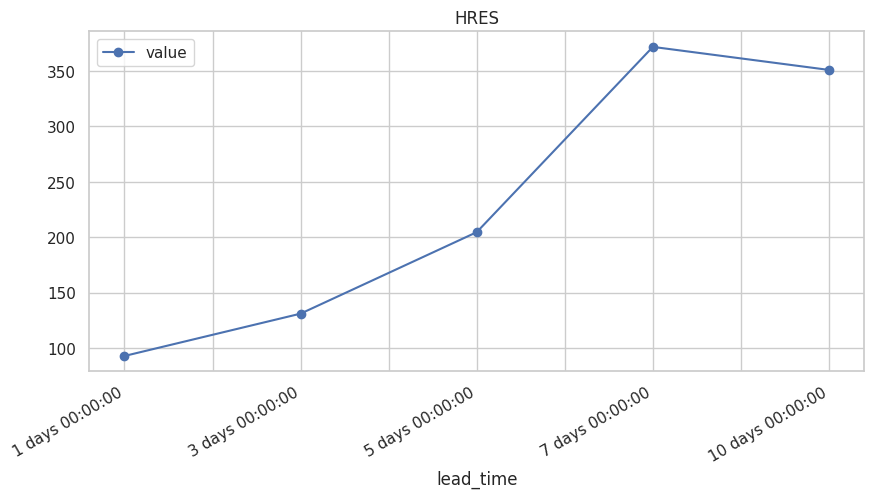

In [66]:
test_results = aifs_tc_results[['value', 'metric', 'lead_time']].groupby(['lead_time','metric']).mean()
test_results = test_results.reset_index()
test_results[test_results['metric'] == 'landfall_displacement'].plot(x='lead_time', y='value',kind='line',marker='o', figsize=(10,5))
plt.title('AIFS')

test_results = pangu_tc_results[['value', 'metric', 'lead_time']].groupby(['lead_time','metric']).mean()
test_results = test_results.reset_index()
test_results[test_results['metric'] == 'landfall_displacement'].plot(x='lead_time', y='value',kind='line',marker='o', figsize=(10,5))
plt.title('Pangu')
test_results = gc_tc_results[['value', 'metric', 'lead_time']].groupby(['lead_time','metric']).mean()
test_results = test_results.reset_index()
test_results[test_results['metric'] == 'landfall_displacement'].plot(x='lead_time', y='value',kind='line',marker='o', figsize=(10,5))
plt.title('GraphCast')

test_results = hres_tc_results[['value', 'metric', 'lead_time']].groupby(['lead_time','metric']).mean()
test_results = test_results.reset_index()
test_results[test_results['metric'] == 'landfall_displacement'].plot(x='lead_time', y='value',kind='line',marker='o', figsize=(10,5))
plt.title('HRES')

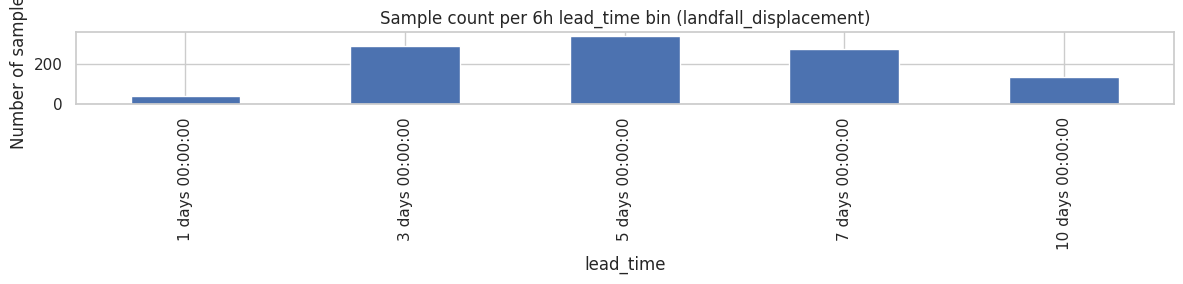

In [67]:
# --- Diagnostic: sample counts per 6h lead_time bin ---
disp = aifs_tc_results[aifs_tc_results['metric'] == 'landfall_displacement'].dropna(subset=['value'])
lead_6h = (disp['lead_time'].dt.total_seconds() / 3600 / 6).round() * 6
counts = lead_6h.value_counts().sort_index()
counts.index = pd.to_timedelta(counts.index, unit='h')
counts.index.name = 'lead_time'
counts.name = 'n_samples'

fig, ax = plt.subplots(figsize=(12, 3))
counts.plot.bar(ax=ax)
ax.set_ylabel('Number of samples')
ax.set_title('Sample count per 6h lead_time bin (landfall_displacement)')
plt.tight_layout()

In [68]:
# Which cases drive high error at small lead times?
disp = aifs_tc_results[
    aifs_tc_results['metric'] == 'landfall_displacement'
].dropna(subset=['value']).copy()

small_lead = disp[disp['lead_time'] <= pd.Timedelta(days=2)]
print(f"Rows with lead_time <= 2 days: {len(small_lead)}")
print(f"Mean displacement (lead <= 2d): {small_lead['value'].mean():.1f} km")
print(f"Mean displacement (all):        {disp['value'].mean():.1f} km\n")

print("Per-case breakdown (lead <= 2 days):")
case_summary = (
    small_lead
    .groupby('case_id_number')
    .agg(n=('value', 'count'), mean_disp=('value', 'mean'), max_disp=('value', 'max'))
    .sort_values('mean_disp', ascending=False)
)
print(case_summary.to_string())

Rows with lead_time <= 2 days: 40
Mean displacement (lead <= 2d): 56.5 km
Mean displacement (all):        179.2 km

Per-case breakdown (lead <= 2 days):
                 n  mean_disp    max_disp
case_id_number                           
214              8  135.52168  479.033474
159              2   67.04098    67.04098
216              2  53.742412   53.742412
192             16  39.297189  103.323791
253              4  35.262647   66.261703
195              6  23.211412   25.113566
187              2  13.003488   13.003488


In [69]:
# Inspect landfall pairings for outlier cases
# For the top 5 highest-error cases at small lead times, show
# which observed landfalls exist and what init_times are involved.
disp = aifs_tc_results[
    aifs_tc_results['metric'] == 'landfall_displacement'
].dropna(subset=['value']).copy()
disp['value'] = pd.to_numeric(disp['value'])
small_lead = disp[disp['lead_time'] <= pd.Timedelta(days=2)]

top_cases = (
    small_lead
    .groupby('case_id_number')['value']
    .mean()
    .nlargest(5)
    .index.tolist()
)

for case_id in top_cases:
    print(f"\n{'='*60}")
    print(f"Case {case_id}")
    print(f"{'='*60}")

    lf = landfalls_dict.get(case_id)
    if lf is not None and len(lf) > 0:
        print(f"  Observed landfalls ({len(lf.valid_time)}):")
        for j in range(len(lf.valid_time)):
            vt = pd.Timestamp(lf.valid_time.values[j])
            lat = float(lf.latitude.values[j])
            lon = float(lf.longitude.values[j])
            print(f"    #{j}: {vt}  ({lat:.2f}, {lon:.2f})")
    else:
        print("  No observed landfalls in landfalls_dict")

    case_rows = small_lead[small_lead['case_id_number'] == case_id]
    print(f"\n  Rows with lead <= 2d ({len(case_rows)}):")
    cols = ['init_time', 'lead_time', 'value']
    avail = [c for c in cols if c in case_rows.columns]
    print(case_rows[avail].sort_values('lead_time').to_string(index=False))


Case 214
  Observed landfalls (5):
    #0: 2021-07-05 18:27:05.668837632  (22.19, -81.59)
    #1: 2021-07-05 21:47:34.318032037  (22.68, -81.93)
    #2: 2021-07-07 14:11:14.945338902  (29.71, -83.51)
    #3: 2021-07-09 15:03:00.238513483  (40.92, -72.28)
    #4: 2021-07-10 01:36:04.096416303  (44.69, -67.34)

  Rows with lead <= 2d (8):
          init_time lead_time      value
2021-07-04 12:00:00    1 days  26.137284
2021-07-04 18:00:00    1 days 479.033474
2021-07-05 00:00:00    1 days  26.137284
2021-07-05 06:00:00    1 days  10.778679
2021-07-04 12:00:00    1 days  26.137284
2021-07-04 18:00:00    1 days 479.033474
2021-07-05 00:00:00    1 days  26.137284
2021-07-05 06:00:00    1 days  10.778679

Case 159
  Observed landfalls (6):
    #0: 2024-07-17 12:51:10.379908738  (11.76, 125.47)
    #1: 2024-07-17 18:12:31.847764975  (12.11, 123.94)
    #2: 2024-07-17 23:25:17.369139185  (12.46, 122.63)
    #3: 2024-07-18 07:38:41.012165115  (12.65, 121.54)
    #4: 2024-07-21 17:11:43.0698643

In [70]:
global_tc_error

{'Landfall Wind Speed MAE': array([[11.63152853, 15.83004229, 14.00418673, 15.21524188,  4.4932106 ],
        [12.40712835, 18.45635808, 17.32697984, 18.15008927, 15.593344  ],
        [12.89960747, 18.90529796, 19.30157352, 16.49739619, 13.14484101],
        [11.88412249, 17.58827954, 19.75178837, 15.81045128, 14.39101645]]),
 'Landfall Min Pressure MAE': array([[ 857.39528348, 1700.4470513 , 1649.81042249, 2069.36578477,
         1303.40917317],
        [1089.31679634, 1833.38859459, 1713.70949787, 1724.31612457,
         1830.45992207],
        [1072.63866124, 1949.28384806, 1992.32854395, 1880.73942573,
         1421.33714342],
        [ 790.5405281 , 1623.39971656, 1923.81181367, 1496.95683471,
         1532.37396775]]),
 'Landfall Time ME': array([[-0.14944776,  0.62051936, -0.17424761, -2.31450078, -4.80709278],
        [ 1.59541223,  0.87743138,  0.50096813, -2.7179059 , -5.10376045],
        [ 2.21953227,  1.51559312, -0.6295545 , -3.47036128, -5.81157669],
        [-0.1068518

(32, 22.0)
plotting the cases for each event type


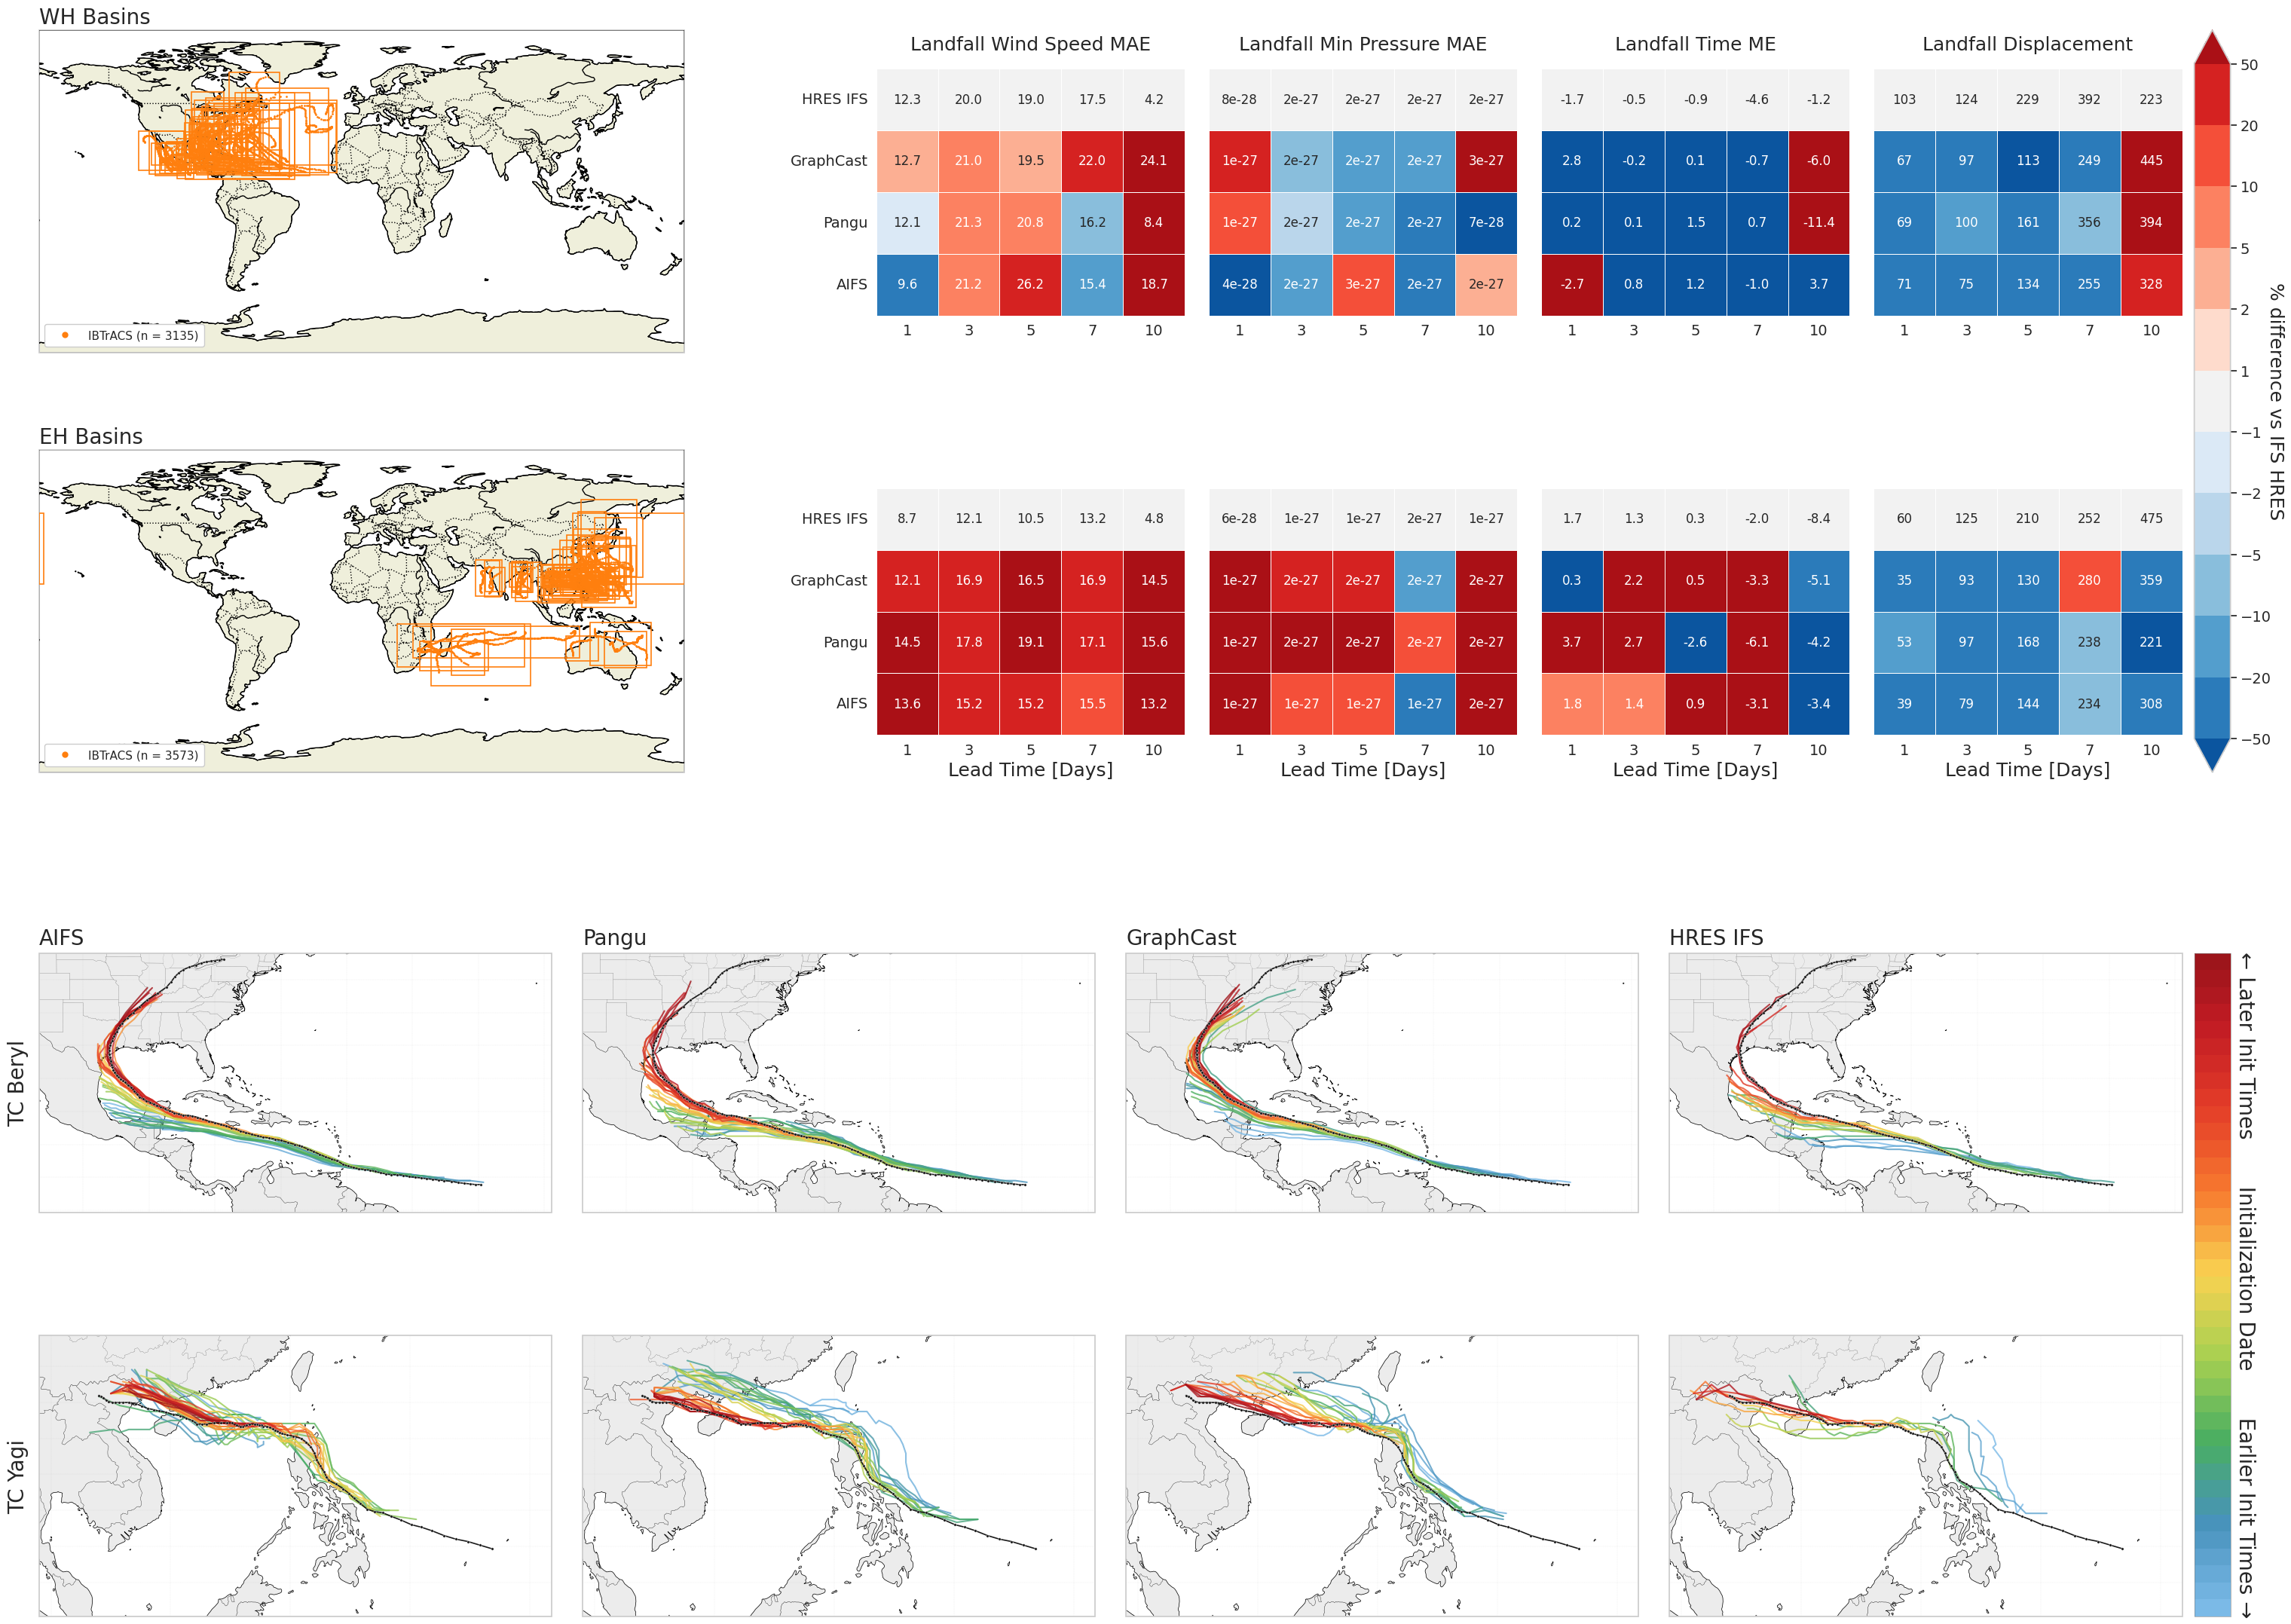

In [85]:
%matplotlib inline
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from src.plots.figure5_tc_tracks import (
    plot_tc_panel, _load_nc, _get_shared_extent, _add_basemap,
    MODEL_COLS, STORM_ROWS, EXTENT_CRS,
    TITLE_FONTSIZE, STORM_LABEL_FONTSIZE, CBAR_LABEL_FONTSIZE,
)
from pathlib import Path as _Path
TC_DATA_DIR = _Path.home() / "code" / "ewb_tc_track_mapper" / "data" / "a2130f5"

n_rows_top = 2
n_rows_bottom = 2
n_rows = n_rows_top + n_rows_bottom
n_cols_top = 2
n_cols_bottom = 4
figsize = (8 * max(n_cols_top, n_cols_bottom), 5.5 * n_rows)
print(figsize)

fig = plt.figure(figsize=figsize)

# gs_main uses TWO columns:
#   col 0 — all content (basin maps, heatmaps, TC panels) for BOTH top
#            and bottom sections.  This guarantees the left edge of col 0
#            of gs_top (basin maps) == the left edge of col 0 of gs_bottom
#            (TC Beryl/Yagi first column) by construction.
#   col 1 — thin dedicated strip for the shared colorbar, only used by
#            the bottom section.  Its left edge == the right edge of col 0,
#            which is also the right edge of the rightmost heatmap column.
gs_main = GridSpec(
    n_rows, 2, figure=fig,
    left=0.05, right=0.97, top=0.98, bottom=0.02,
    wspace=0.01, hspace=0.6,
    height_ratios=[1, 1, 0.9, 0.9],
    width_ratios=[1, 0.03],
)

# Top section: basin maps (col 0) + heatmaps (col 1) inside gs_main col 0
gs_top = GridSpecFromSubplotSpec(
    n_rows_top, n_cols_top,
    subplot_spec=gs_main[0:n_rows_top, 0],
    wspace=0.02, hspace=0.3,
    width_ratios=[1, 1.6],
)

# Bottom section: 4 TC-track columns inside gs_main col 0
gs_bottom = GridSpecFromSubplotSpec(
    n_rows_bottom, n_cols_bottom,
    subplot_spec=gs_main[n_rows_top:n_rows, 0],
    wspace=0.06, hspace=0.35,
)

max_cols = max(n_cols_top, n_cols_bottom)
axs = np.empty((n_rows, max_cols), dtype=object)

for i in range(n_rows_top):
    axs[i, 0] = fig.add_subplot(
        gs_top[i, 0], projection=ccrs.PlateCarree(),
    )
    axs[i, 1] = fig.add_subplot(gs_top[i, 1])

for i in range(n_rows_bottom):
    for j in range(n_cols_bottom):
        axs[i + n_rows_top, j] = fig.add_subplot(
            gs_bottom[i, j], projection=ccrs.PlateCarree(),
        )

# --- top rows: basin maps + heatmaps ---
print("plotting the cases for each event type")

plot_utils.plot_all_cases_and_obs(
    ab_subset,
    event_type="tropical_cyclone",
    targets=case_operators_with_targets_established,
    title="WH Basins",
    ax=axs[0, 0],
)
axs[0, 0].set_title("WH Basins", loc="left", fontsize=20)
axs[0, 0].set_title("", loc="center")
plot_utils.plot_all_cases_and_obs(
    pb_subset,
    event_type="tropical_cyclone",
    targets=case_operators_with_targets_established,
    title="EH Basins",
    ax=axs[1, 0],
)
axs[1, 0].set_title("EH Basins", loc="left", fontsize=20)
axs[1, 0].set_title("", loc="center")

tc_settings = {}
tc_settings["subplot_titles"] = tc_display_str
tc_settings["metric_str"] = tc_display_str
tc_settings["lead_time_days"] = lead_time_days
tc_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

# Pressure MAE is stored in Pa; convert to hPa for display.
_pressure_key = "Landfall Min Pressure MAE"
ab_tc_error[_pressure_key] = ab_tc_error[_pressure_key] / 100
pb_tc_error[_pressure_key] = pb_tc_error[_pressure_key] / 100

# Top row: show heatmap titles, hide x-axis label
scorecard_mappable = plot_utils.plot_heatmap(
    ab_rel_tc_error,
    ab_tc_error,
    tc_settings,
    ax=axs[0, 1],
    return_mappable=True,
    show_titles=True,
    show_xlabel=False,
)

# Bottom row: hide titles, show x-axis label only
plot_utils.plot_heatmap(
    pb_rel_tc_error,
    pb_tc_error,
    tc_settings,
    ax=axs[1, 1],
    show_titles=False,
    show_xlabel=True,
)


# Row 1 = TC Beryl, Row 2 = TC Yagi
# Columns = AIFS, Pangu, GraphCast, HRES IFS

# Derive cell_aspect from the GridSpec geometry so generate_extent
# produces extents that exactly fill each subplot cell, giving all
# 8 panels a consistent aspect ratio.
_cell_pos = gs_bottom[0, 0].get_position(fig)
_fw, _fh = fig.get_size_inches()
tc_cell_aspect = (_cell_pos.width * _fw, _cell_pos.height * _fh)

row_extents = {
    cid: _get_shared_extent(cid, tc_cell_aspect)
    for cid, _ in STORM_ROWS
}

# representative_sm is collected from the first successfully rendered
# panel and used later for the single shared colorbar.
representative_sm = None

for row_idx, (case_id, storm_label) in enumerate(STORM_ROWS):
    extent = row_extents[case_id]
    grid_row = row_idx + n_rows_top

    for col_idx, (model_dir, display_name) in enumerate(MODEL_COLS):
        ax = axs[grid_row, col_idx]
        nc_path = (
            TC_DATA_DIR / model_dir
            / f"case_{case_id:03d}.nc"
        )

        if not nc_path.exists():
            _add_basemap(ax)
            if extent is not None:
                ax.set_extent(extent, crs=EXTENT_CRS)
            ax.text(
                0.5, 0.5, "Data not yet\ngenerated",
                transform=ax.transAxes,
                ha="center", va="center",
                fontsize=7, color="gray", style="italic",
            )
            if row_idx == 0:
                ax.set_title(
                    display_name,
                    fontsize=TITLE_FONTSIZE,
                    fontweight="bold", pad=8,
                )
            if col_idx == 0:
                ax.text(
                    -0.02, 1.03, storm_label,
                    transform=ax.transAxes,
                    fontsize=STORM_LABEL_FONTSIZE,
                    fontweight="bold",
                    va="bottom", ha="left",
                )
            continue

        track_data, analysis_data = _load_nc(nc_path)
        sm_, _ = plot_tc_panel(
            track_data, analysis_data, display_name,
            ax=ax, fig=fig, extent=extent,
            show_col_title=(row_idx == 0),
            storm_label=(
                storm_label if col_idx == 0 else None
            ),
            add_colorbar=False,
        )
        if representative_sm is None:
            representative_sm = sm_

# --- post-draw: left-align all map panels ---
# Cartopy centers each GeoAxes within its GridSpec cell when the map's
# natural aspect ratio differs from the cell's aspect ratio.  After one
# draw we know the Cartopy-computed width/height; left-aligning (setting
# x0 = cell.x0) moves the panel flush with the cell left edge without
# distorting the map, because the box dimensions already satisfy the
# required aspect ratio so apply_aspect won't re-center on future draws.
fig.canvas.draw()

# Left-align basin maps (world map is narrower than its wide cell)
for i in range(n_rows_top):
    ax = axs[i, 0]
    cell_pos = gs_top[i, 0].get_position(fig)
    ax_pos = ax.get_position()
    ax.set_position([cell_pos.x0, ax_pos.y0, ax_pos.width, ax_pos.height])

# Left-align TC track panels and re-apply extents so the geographic
# extent stays consistent after the position change.
for row_idx, (case_id, _) in enumerate(STORM_ROWS):
    for col_idx in range(n_cols_bottom):
        ax = axs[row_idx + n_rows_top, col_idx]
        if ax is None:
            continue
        cell_pos = gs_bottom[row_idx, col_idx].get_position(fig)
        ax_pos = ax.get_position()
        ax.set_position([cell_pos.x0, ax_pos.y0, ax_pos.width, ax_pos.height])
        if row_extents[case_id] is not None:
            ax.set_extent(row_extents[case_id], crs=EXTENT_CRS)

# --- right-side colorbars (heatmap scorecard + TC track init date) ---
# Both share the gs_main col-1 strip so they form a single visual column
# aligned with the right edge of the heatmaps and TC panels.
fig.canvas.draw()

# 1) Heatmap scorecard colorbar — spans WH and EH heatmap rows.
plot_utils.add_scorecard_colorbar_right(
    fig,
    scorecard_mappable,
    [axs[0, 1], axs[1, 1]],
    n_subplots=2,
    pad=0.005,
    width=0.015,
)

# 2) TC track initialization-date colorbar — spans TC Beryl and TC Yagi rows.
cbar_strip = gs_main[n_rows_top:n_rows, 1].get_position(fig)
ax_top_pos = axs[n_rows_top, 0].get_position()
ax_bot_pos = axs[
    n_rows_top + n_rows_bottom - 1, n_cols_bottom - 1
].get_position()

# Match the heatmap colorbar width and x-position for visual consistency.
_hm_cbar_x = max(
    axs[0, 1].get_position().x1, axs[1, 1].get_position().x1
) + 0.005
cbar_w = 0.015
cbar_ax = fig.add_axes([
    _hm_cbar_x,
    ax_bot_pos.y0,
    cbar_w,
    ax_top_pos.y1 - ax_bot_pos.y0,
])

if representative_sm is not None:
    cbar = fig.colorbar(
        representative_sm, cax=cbar_ax, orientation="vertical",
    )
    cbar.set_ticks([])
    cbar.outline.set_linewidth(0.4)
    cbar.outline.set_edgecolor("gray")
    cbar.ax.set_ylabel(
        "\u2190 Later Init Times       Initialization Date"
        "       Earlier Init Times \u2192",
        rotation=270,
        labelpad=14,
        fontsize=20,
        va="center",
    )
plt.show()
